# Correlaciones entre Features y Outliers

Aquí ya no miramos el target, sino cómo se relacionan **las features entre sí** (para detectar multicolinealidad) y qué outliers hay en tráfico y meteorología.

Trabajamos siempre sobre `train.csv`.

**Qué vamos a ver:**
1. Heatmap de correlación entre features
2. Outliers en las variables de tráfico
3. Outliers en las variables de meteorología

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ruta = "../data_sample/"
train = pd.read_parquet(ruta + "train.parquet")

variables_trafico = ["intensidad_mean", "intensidad_max", "ocupacion_mean", "carga_mean", "vmed_mean", "vmed_max"]
variables_meteo = ["temperatura", "humedad", "viento_vel", "precipitacion"]
todas_las_features = variables_trafico + variables_meteo

print("Features a analizar:", todas_las_features)

Features a analizar: ['intensidad_mean', 'intensidad_max', 'ocupacion_mean', 'carga_mean', 'vmed_mean', 'vmed_max', 'temperatura', 'humedad', 'viento_vel', 'precipitacion']


## 1. Correlación entre features (multicolinealidad)



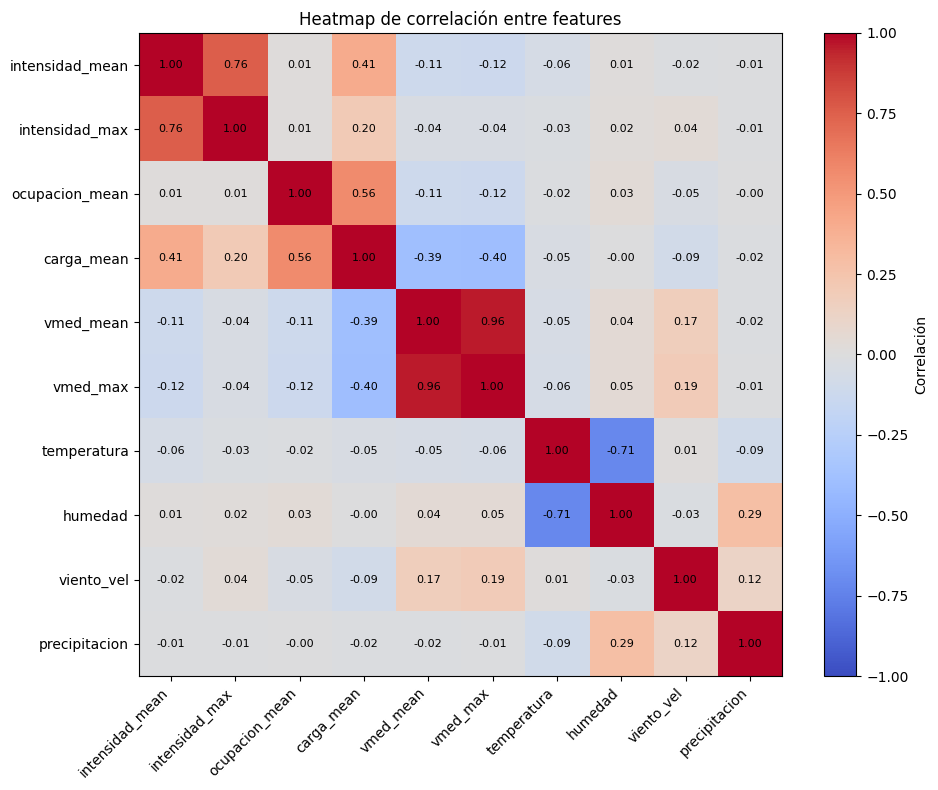

In [2]:
matriz_correlacion = train[todas_las_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(matriz_correlacion, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.xticks(range(len(todas_las_features)), todas_las_features, rotation=45, ha="right")
plt.yticks(range(len(todas_las_features)), todas_las_features)

# Escribimos el numero de correlacion dentro de cada celda
for i in range(len(todas_las_features)):
    for j in range(len(todas_las_features)):
        valor = matriz_correlacion.iloc[i, j]
        plt.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8)

plt.title("Heatmap de correlación entre features")
plt.tight_layout()
plt.show()



**Qué buscar aquí**: las celdas con valores muy altos (por encima de 0.8 o 0.9, en positivo o negativo) fuera de la diagonal — esas son parejas de variables casi "redundantes". Es esperable, por ejemplo, que `intensidad_mean` e `intensidad_max` estén bastante correlacionadas entre sí (ambas miden "cuánto tráfico hay", una en promedio y otra en el pico).

In [3]:
# Buscamos automaticamente los pares de variables con correlacion muy alta 
pares_altos = []

for i in range(len(todas_las_features)):
    for j in range(i+1, len(todas_las_features)):
        valor = matriz_correlacion.iloc[i, j]
        if abs(valor) > 0.7:
            pares_altos.append({
                "variable_1": todas_las_features[i],
                "variable_2": todas_las_features[j],
                "correlacion": round(valor, 3)
            })

pd.DataFrame(pares_altos).sort_values("correlacion", key=abs, ascending=False)

,variable_1,variable_2,correlacion
1,vmed_mean,vmed_max,0.961
0,intensidad_mean,intensidad_max,0.755
2,temperatura,humedad,-0.715


**¿Qué significa esto?** En vez de buscar a ojo en el heatmap, aquí filtramos automáticamente solo los pares con correlación mayor a 0.7 (en valor absoluto) — el umbral habitual para considerar que hay multicolinealidad relevante. 

### Pairplot de variables seleccionadas

El heatmap nos da los números exactos, pero un pairplot nos deja **ver la forma** de esas relaciones (¿es una línea recta? ¿una nube sin forma? ¿una curva?). Seleccionamos algunas variables representativas (no las 10 a la vez, porque sería ilegible): una de tráfico (`intensidad_mean`), una de velocidad (`vmed_mean`), y las 3 de meteo principales.

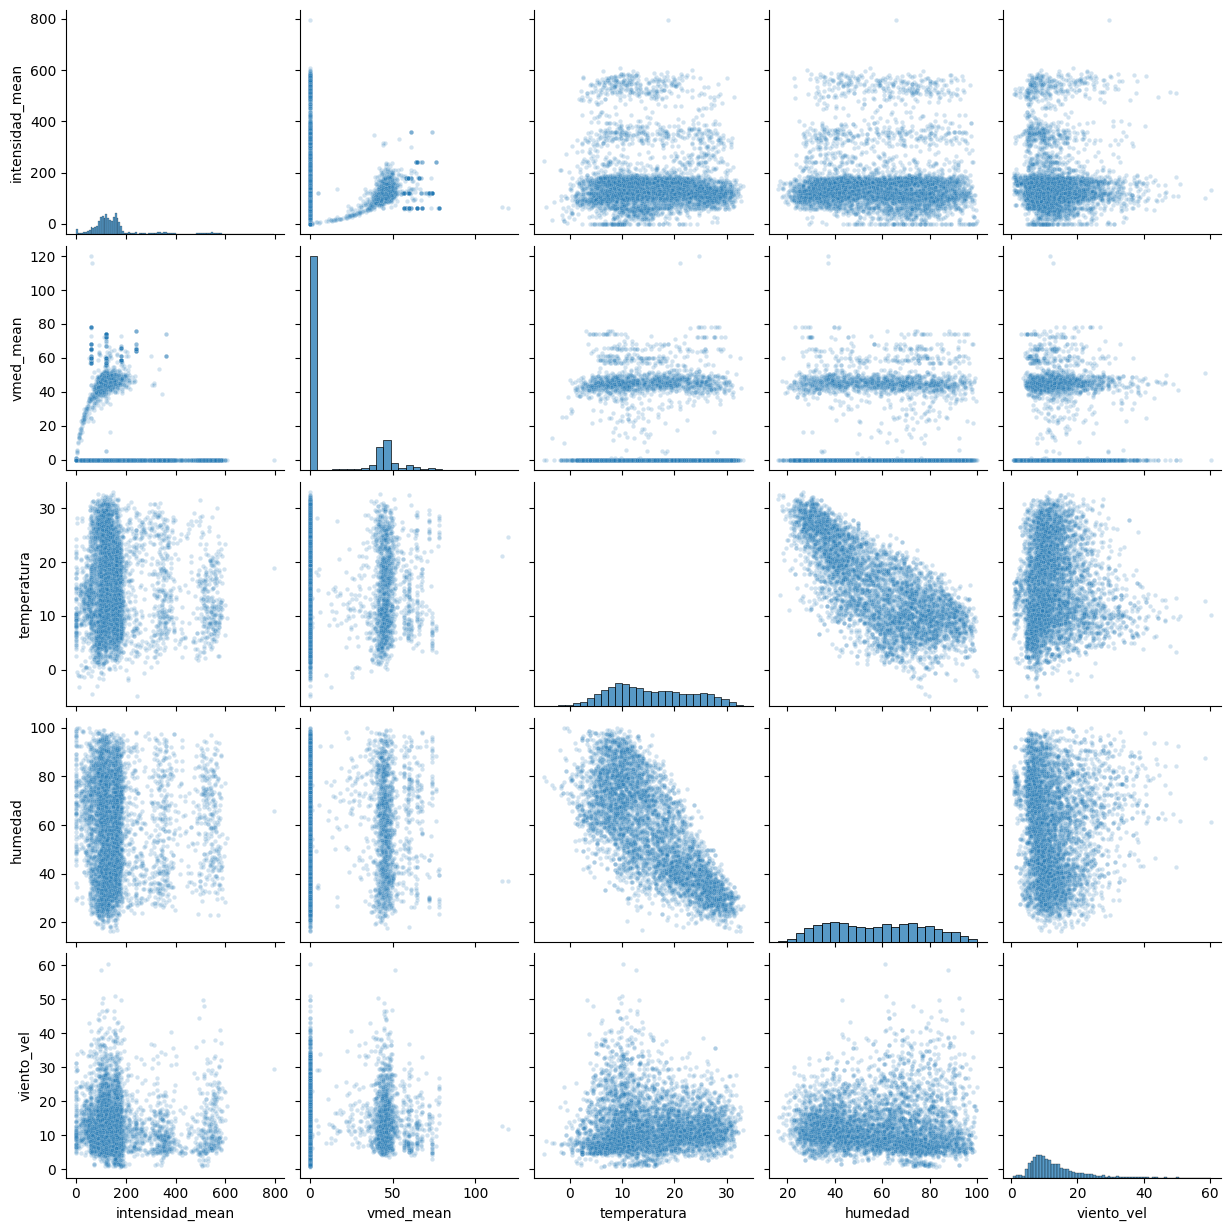

In [4]:
import seaborn as sns

variables_seleccionadas = ["intensidad_mean", "vmed_mean", "temperatura", "humedad", "viento_vel"]

sns.pairplot(train[variables_seleccionadas].dropna(), diag_kind="hist", plot_kws={"alpha": 0.2, "s": 10})
plt.show()

**¿Qué significa esto?** Cada casilla fuera de la diagonal es un scatter plot entre dos variables (como los que ya vimos, pero ahora cruzando features entre sí). La diagonal muestra un histograma de cada variable por separado (su distribución individual).

**Qué mirar aquí**: busca nubes de puntos con forma clara de línea (relación fuerte) frente a nubes redondas y dispersas sin forma (relación débil). Es la misma información que el heatmap, pero de un vistazo visual en vez de solo números.

## 2. Outliers en las variables de tráfico

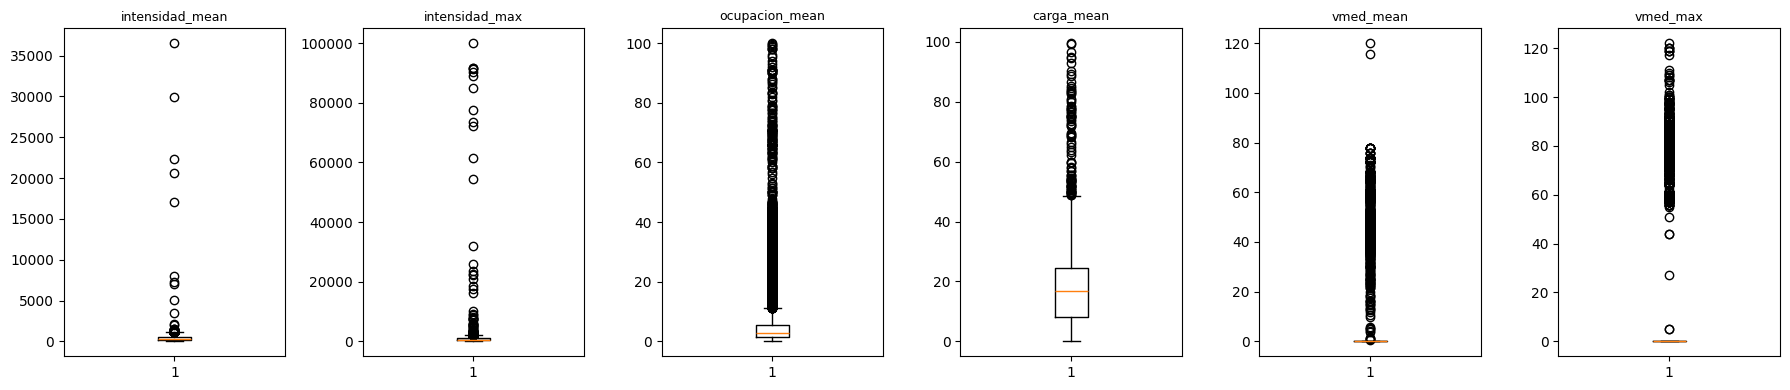

In [5]:
fig, axes = plt.subplots(1, len(variables_trafico), figsize=(18, 4))

for ax, variable in zip(axes, variables_trafico):
    ax.boxplot(train[variable].dropna())
    ax.set_title(variable, fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# Calculamos el porcentaje de outliers (metodo IQR) para cada variable de trafico
resumen_outliers_trafico = []

for variable in variables_trafico:
    datos = train[variable].dropna()
    q1, q3 = datos.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = datos[(datos < limite_inf) | (datos > limite_sup)]

    resumen_outliers_trafico.append({
        "variable": variable,
        "num_outliers": len(outliers),
        "pct_outliers": round(len(outliers) / len(datos) * 100, 1)
    })

pd.DataFrame(resumen_outliers_trafico)

,variable,num_outliers,pct_outliers
0,intensidad_mean,242,1.0
1,intensidad_max,370,1.5
2,ocupacion_mean,1796,7.4
3,carga_mean,89,0.4
4,vmed_mean,1486,6.1
5,vmed_max,1486,6.1


## 3. Outliers en las variables de meteorología

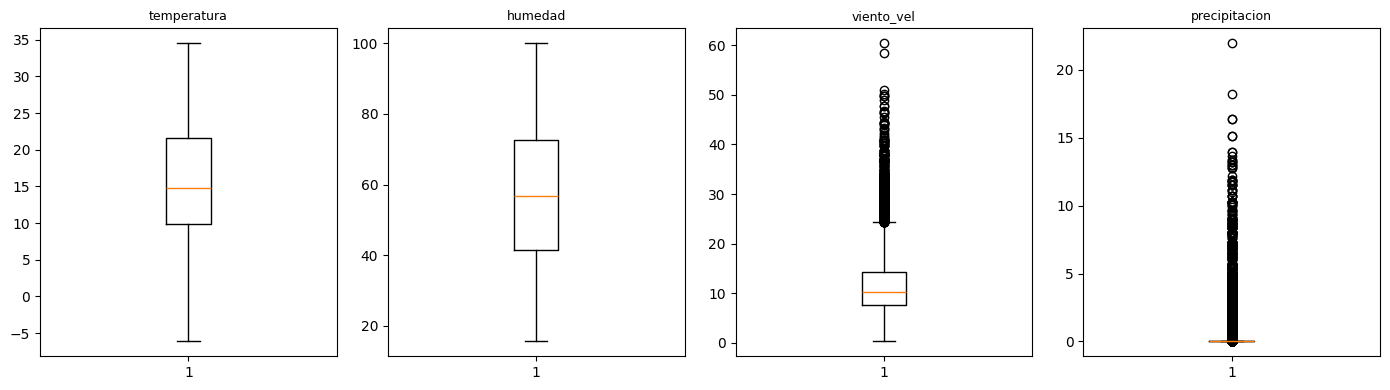

In [7]:
fig, axes = plt.subplots(1, len(variables_meteo), figsize=(14, 4))

for ax, variable in zip(axes, variables_meteo):
    ax.boxplot(train[variable].dropna())
    ax.set_title(variable, fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
resumen_outliers_meteo = []

for variable in variables_meteo:
    datos = train[variable].dropna()
    q1, q3 = datos.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = datos[(datos < limite_inf) | (datos > limite_sup)]

    resumen_outliers_meteo.append({
        "variable": variable,
        "num_outliers": len(outliers),
        "pct_outliers": round(len(outliers) / len(datos) * 100, 1),
        "minimo": round(datos.min(), 1),
        "maximo": round(datos.max(), 1)
    })

pd.DataFrame(resumen_outliers_meteo)

,variable,num_outliers,pct_outliers,minimo,maximo
0,temperatura,0,0.0,-6.1,34.5
1,humedad,0,0.0,15.6,100.0
2,viento_vel,567,4.8,0.3,60.4
3,precipitacion,4316,23.1,0.0,22.0


## Conclusiones

### Sobre la correlación entre features (multicolinealidad)

**¿Qué estábamos mirando?** No si el tráfico o la meteo se relacionan con el NO2 (eso ya lo vimos en el notebook anterior), sino si **las features se parecen demasiado entre sí**.

**Lo que encontramos:**

- **`vmed_mean` y `vmed_max` van casi pegadas (correlación 0.96)**: la velocidad "normal" de un día y el pico más alto de velocidad de ese mismo día suben y bajan juntas casi siempre. Es como preguntar "¿cuánto mides?" y "¿cuánto mide tu cabeza más el resto del cuerpo?" — distintas preguntas, pero casi la misma respuesta. Darle las dos al modelo no aporta mucho más que darle solo una.

- **`intensidad_mean` e `intensidad_max` también van bastante juntas (0.76)**: lo mismo que arriba, aunque algo menos pegadas.

- **`temperatura` y `humedad` van en direcciones opuestas (-0.72)**: cuando sube la temperatura, baja la humedad (y al revés). Tiene sentido real: los días calurosos de Madrid suelen ser secos, los días húmedos suelen ser más fríos.

**¿Es esto un problema que hay que arreglar?** No es un error nuestro, es simplemente un aviso para el equipo de preprocesado: *"estas parejas de variables cuentan casi la misma historia, valorad si hace falta quedaros con las dos o solo con una"*.

**Sobre el pairplot**: confirma visualmente lo que ya decían los números — por ejemplo, la nube de puntos entre `temperatura` y `humedad` debería verse claramente descendente (a más temperatura, menos humedad), mientras que las nubes entre variables poco correlacionadas se ven más redondas y sin forma clara. El pairplot no añade información nueva sobre la que ya teníamos con el heatmap, pero ayuda a "verlo" en vez de solo leer un número, lo cual es útil para explicarlo en la presentación final del equipo.

### Sobre los outliers en las features

**¿Qué estábamos mirando?** Lo mismo que hicimos con el NO2 en el notebook anterior (método IQR), pero ahora aplicado a cada variable de tráfico y meteo por separado — cuántos días tienen un valor "raro" (muy alto o muy bajo) en cada una.

**Por qué revisamos también el mínimo y el máximo en meteo**: porque ya sabemos que esos datos venían con un error de escala que corregimos antes (el problema de los decimales perdidos). Mirar el mínimo/máximo nos ayuda a distinguir entre "un día real de mucho viento" y "un posible error de sensor que se nos haya colado".

